## Workspace setup

In [1]:
from datetime import datetime  
import importlib
import uproot
from functools import partial
import numpy as np
import tensorflow as tf

2025-07-03 11:19:48.432793: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Training dataset preparation

In [2]:
import io_functions as io
importlib.reload(io)

import plotting_functions as plf
importlib.reload(plf)

train_files = ['data/out_C_arr_1.root:TPCData','data/out_C_arr_2.root:TPCData', 'data/out_C_arr_3.root:TPCData', 'data/out_C_arr_4.root:TPCData']
datasetGenerator = partial(io.generator_XYZ_UVWT, files=train_files)

train_dataset = tf.data.Dataset.from_generator(
     datasetGenerator,
     output_signature=(
         tf.TensorSpec(shape=(3), dtype=tf.float64),
         tf.TensorSpec(shape=(4,), dtype=tf.float64)))

test_files = ['data/out_C_arr_5.root:TPCData']
datasetGenerator = partial(io.generator_XYZ_UVWT, files=test_files)

test_dataset = tf.data.Dataset.from_generator(
     datasetGenerator,
     output_signature=(
         tf.TensorSpec(shape=(3), dtype=tf.float64),
         tf.TensorSpec(shape=(4,), dtype=tf.float64)))

2023-04-27 17:40:35.140253: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-04-27 17:40:35.143434: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-04-27 17:40:35.143552: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## Model definition

In [3]:
model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1., input_shape=(3,)),
  #tf.keras.layers.Dense(128, activation='relu'),
  #tf.keras.layers.Dense(128, activation='relu'), 
  #tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(4, activation='linear', kernel_initializer=tf.keras.initializers.Constant([1]))
])

model.compile(tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss="mse",
              metrics=['mse'])
model.summary()

'''
w = model.get_layer(index=1).get_weights()
w[0] = np.array([[0], [-1/1.5], [0]])
w[1] = np.array([99.75/1.5])
model.get_layer(index=1).set_weights(w)
'''

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 3)                 0         
                                                                 
 dense (Dense)               (None, 4)                 16        
                                                                 
Total params: 16
Trainable params: 16
Non-trainable params: 0
_________________________________________________________________


'\nw = model.get_layer(index=1).get_weights()\nw[0] = np.array([[0], [-1/1.5], [0]])\nw[1] = np.array([99.75/1.5])\nmodel.get_layer(index=1).set_weights(w)\n'

## Model training

In [ ]:
%%time

import plotting_functions as plf
importlib.reload(plf)

epochs=1
history = model.fit(train_dataset.batch(10).take(1),
                    verbose = 1,
                    epochs=epochs)

plf.plotTrainHistory(history)

current_time = datetime.now().strftime("%Y_%b_%d_%H_%M_%S")
print("Training start. Current Time =", current_time)
job_dir = "training/" + current_time
model.save(job_dir, save_format='tf')

tf.keras.utils.plot_model(
    model,
    to_file="fig_png/model.png",
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=96,
    layer_range=None,
    show_layer_activations=True,
    show_trainable=False,
)

## Model performance on training data.

Fill Pandas DataFrame with true and response values.

In [5]:
%%time
import utility_functions as utils
importlib.reload(utils)

df = utils.df

for aBatch in test_dataset.batch(1).take(10000): 
    df = utils.fillPandasDataset(aBatch, df, model) 
    
df.describe()    

2023-04-27 17:41:17.430722: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


CPU times: user 1min 22s, sys: 3.27 s, total: 1min 26s
Wall time: 1min 9s


,GEN_X,GEN_Y,GEN_Z,GEN_U,GEN_V,GEN_W,GEN_T,RECO_U,RECO_V,RECO_W,RECO_T
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-2.474880,-0.283581,-41.664387,66.689468,1.117245e+02,1.120351e+02,127.403625,-44.422852,-44.422852,-44.422852,-44.422852
std,82.588356,52.129395,31.853554,34.719223,5.083016e+01,5.012129e+01,98.172241,101.547478,101.547478,101.547478,101.547478
min,-198.368713,-95.828873,-75.571777,2.488592,-1.887379e-14,-5.684342e-14,50.929935,-302.708618,-302.708618,-302.708618,-302.708618
25%,-61.894854,-45.032720,-66.387604,37.033988,7.484614e+01,7.567401e+01,51.099998,-117.759787,-117.759787,-117.759787,-117.759787
50%,-1.958492,-1.235388,-66.387604,67.323593,1.116349e+02,1.120896e+02,51.099998,-42.569714,-42.569714,-42.569714,-42.569714
75%,57.608350,44.454007,-16.719201,96.467123,1.486044e+02,1.490562e+02,204.109879,29.565279,29.565279,29.565279,29.565279
max,186.112488,96.017113,39.225578,130.385910,2.260000e+02,2.270000e+02,377.066589,194.924652,194.924652,194.924652,194.924652


### Resolution plots

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, figsize=(8,8))

for index, coordName in enumerate(["U", "V", "W", "T"]):
    axis = axes.flatten()[index]  
    varName1 = "GEN_"+coordName
    varName2 = "RECO_"+coordName
    mean = (df[varName2] - df[varName1]).mean()
    std = (df[varName2] - df[varName1]).std()
    label = "$\mu = {:.3f}$\n$\sigma = {:.2f}$".format(mean, std)
    (df[varName2] - df[varName1]).hist(ax=axis, bins=40, label=label)
    axis.set_xlabel(coordName+" [strips]")
    axis.set_ylabel("")  
    axis.grid(False)
    #axis.legend()
    #axis.legend(bbox_to_anchor=(2.5,1), loc='upper left')

    fig.suptitle("XYZ -> UVW resolution")
    plt.subplots_adjust(bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.3) 
    plt.savefig("fig_png/XYZ_to_UVWT_resolution.png", bbox_inches="tight")   

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(1,3, figsize=(15,5))
df.plot.scatter("GEN_X", "GEN_Y", c = "GEN_U",ax=axes[0]);
df.plot.scatter("GEN_X", "GEN_Y", c = "GEN_V",ax=axes[1]);
df.plot.scatter("GEN_X", "GEN_Y", c = "GEN_W",ax=axes[2]);

plt.subplots_adjust(bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.7) 

/tmp/ipykernel_7175/3473525717.py:21: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  (uvwt - df[["GEN_U", "GEN_V", "GEN_W", "GEN_T"]]).hist(bins=np.linspace(-2,2, 10), ax=axis);


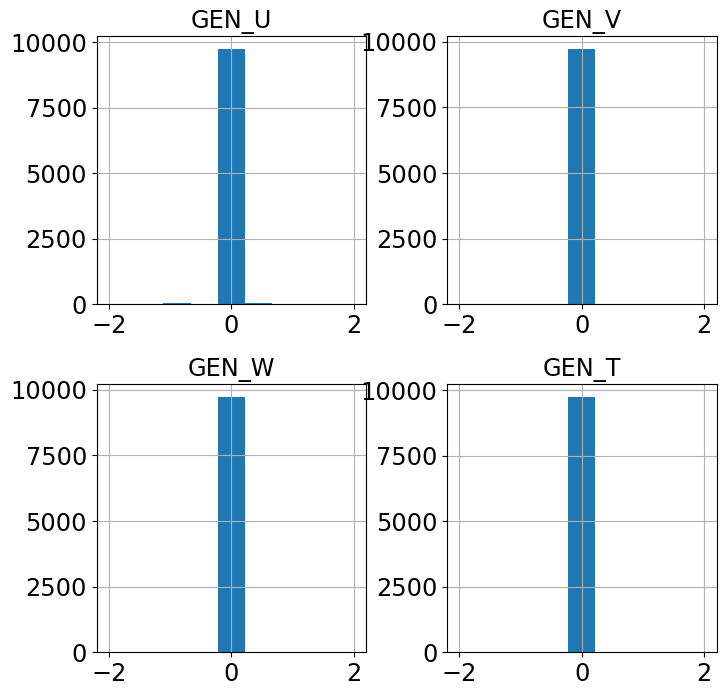

In [48]:
def XYZtoUVWT(x,y,z):
    referencePoint = np.array([-138.9971, 98.25])
    phi = np.pi/6.0
    stripPitch = 1.5
    f = 1.0/12.5*4.05
    u = -(y-99.75)
    v = (x-referencePoint[0])*np.cos(phi) - (y-referencePoint[1])*np.sin(phi)
    w = (x-referencePoint[0])*np.cos(-phi) - (y-referencePoint[1])*np.sin(-phi) + 98.75
    t = z/f + 256
    u/=stripPitch
    v/=stripPitch
    w/=stripPitch
    return np.array((u,v,w,t)).T
    

import matplotlib.pyplot as plt
fig, axis = plt.subplots(1,1, figsize=(8,8))

uvwt = XYZtoUVWT(df["GEN_X"], df["GEN_Y"], df["GEN_Z"])

(uvwt - df[["GEN_U", "GEN_V", "GEN_W", "GEN_T"]]).hist(bins=np.linspace(-2,2, 10), ax=axis);
#(uvw - df[["GEN_U", "GEN_V", "GEN_W"]]).min(axis=0)


#df["GEN_T"].hist(ax=axis)

#f = 1.0/12.5*4.05

#t = df["GEN_Z"]/f

#(df["GEN_T"] - df["GEN_Z"]/f - 256).head()
#df.plot.scatter("GEN_Z", "GEN_T", ax=axis)
#df.plot.scatter("GEN_Y", "GEN_U")

In [25]:

1.0/12.5*4.05

0.324